# Frequency vs Tb_K Visualization

This notebook loads the dataset and visualizes **frequency vs tb_k for each record**.

- Each record is plotted as a line across frequencies.
- Requires the CSV file `mp3000a_lv1_sintetico.csv` in root directory.


In [17]:
import pandas as pd
import matplotlib.pyplot as plt


In [20]:
# Load dataset
df = pd.read_csv("../../mp3000a_lv1_sintetico.csv")
df.dropna(subset=["tb_k"])

# Preview
df.head()


,record_no,datetime_utc,record_type,channel_mhz,frequency_ghz,elevation_deg,azimuth_deg,tb_k,tamb_c,rh_pct,pressure_hpa,rain_flag
0,1,04/22/2026 14:27:36,41,NaN,NaN,NaN,NaN,NaN,25.399,76.111,1013.701,0
1,2,04/22/2026 14:27:36,51,22234.0,22.234,20.0,0.0,286.6492,25.399,76.111,1013.701,0
2,3,04/22/2026 14:27:36,51,22500.0,22.500,20.0,0.0,286.5905,25.399,76.111,1013.701,0
3,4,04/22/2026 14:27:36,51,23034.0,23.034,20.0,0.0,280.4226,25.399,76.111,1013.701,0
4,5,04/22/2026 14:27:36,51,23834.0,23.834,20.0,0.0,241.9748,25.399,76.111,1013.701,0


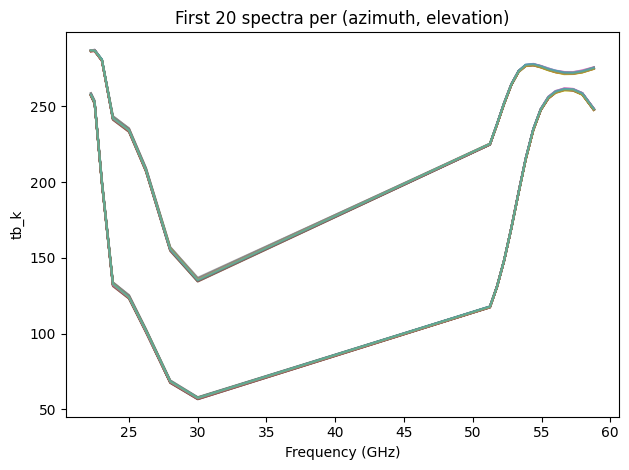

In [23]:
# Remove rows without valid frequency/tb_k
df_clean = df.dropna(subset=["frequency_ghz", "tb_k"])

# Group into spectra (each scan)
spectra = df_clean.groupby(["datetime_utc", "azimuth_deg", "elevation_deg"])

# Re-group by only (az, el)
from collections import defaultdict
azel_groups = defaultdict(list)

for (dt, az, el), group in spectra:
    azel_groups[(az, el)].append(group)

# Plot
for (az, el), group_list in azel_groups.items():
    # Take first 20 spectra for this (az, el)
    for group in group_list[:10]:
        group = group.sort_values("frequency_ghz")
        
        plt.plot(group["frequency_ghz"], group["tb_k"], alpha=0.5)

plt.xlabel("Frequency (GHz)")
plt.ylabel("tb_k")
plt.title("First 20 spectra per (azimuth, elevation)")
plt.tight_layout()
plt.show()


In [24]:
for (az, el), group_list in azel_groups.items():
    print(f"(az={az}, el={el}) → {len(group_list)} spectra")

g1 = azel_groups[(0.0, 20.0)][0]
g2 = azel_groups[(0.0, 20.0)][1]

print((g1["tb_k"].values - g2["tb_k"].values).max())

(az=0.0, el=20.0) → 360 spectra
(az=0.0, el=90.0) → 360 spectra
(az=0.0, el=160.0) → 360 spectra
(az=45.0, el=20.0) → 360 spectra
(az=45.0, el=160.0) → 360 spectra
(az=90.0, el=20.0) → 360 spectra
(az=90.0, el=160.0) → 360 spectra
(az=135.0, el=20.0) → 360 spectra
(az=135.0, el=160.0) → 360 spectra
0.47050000000001546


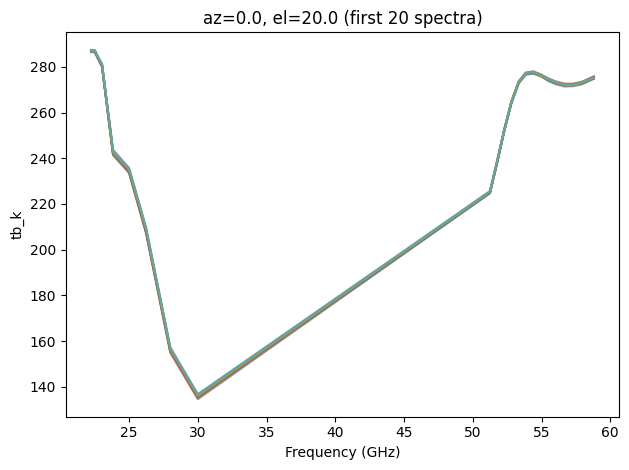

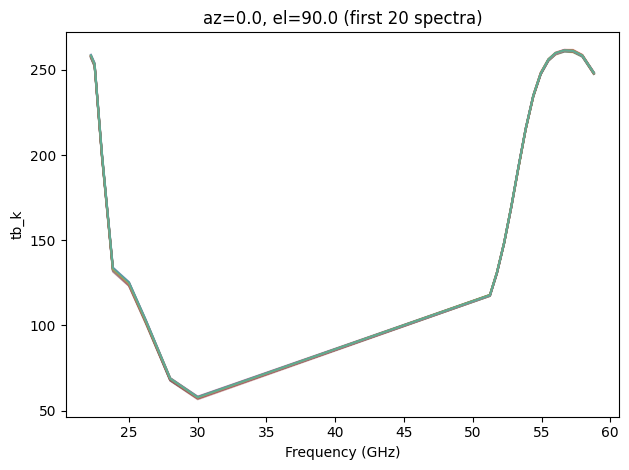

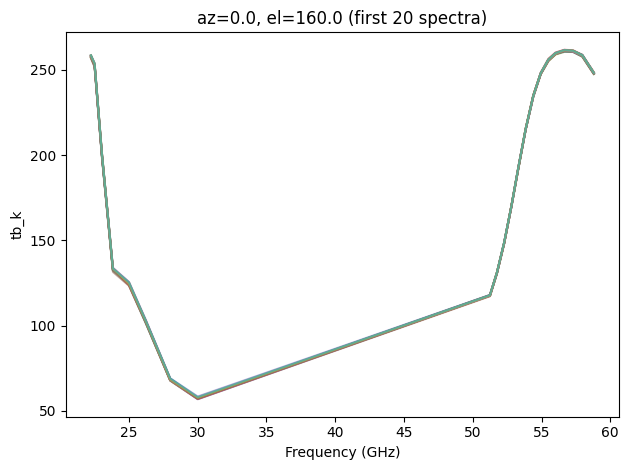

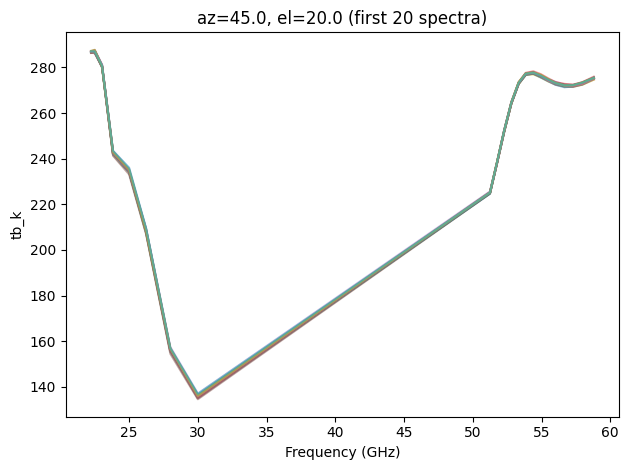

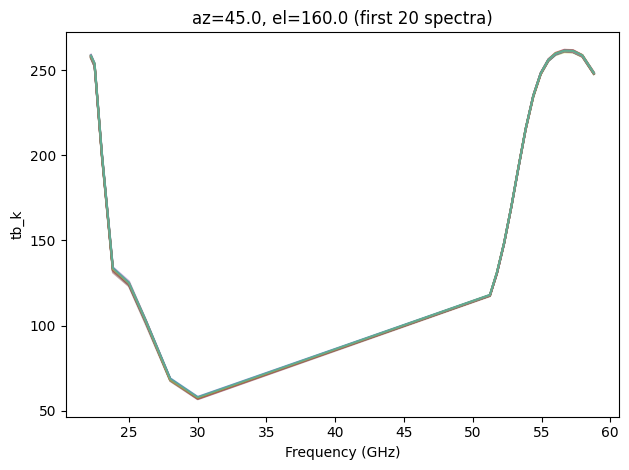

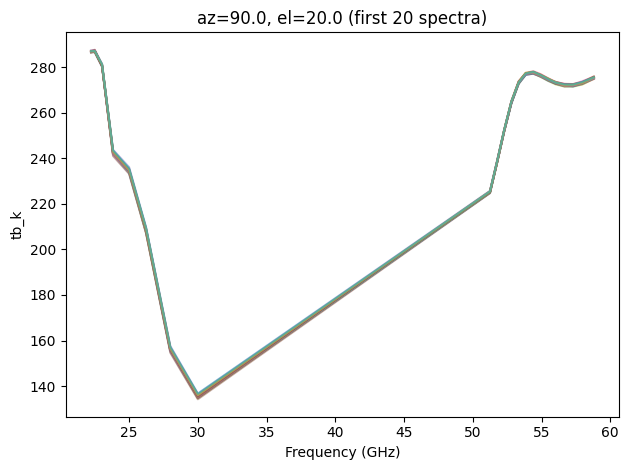

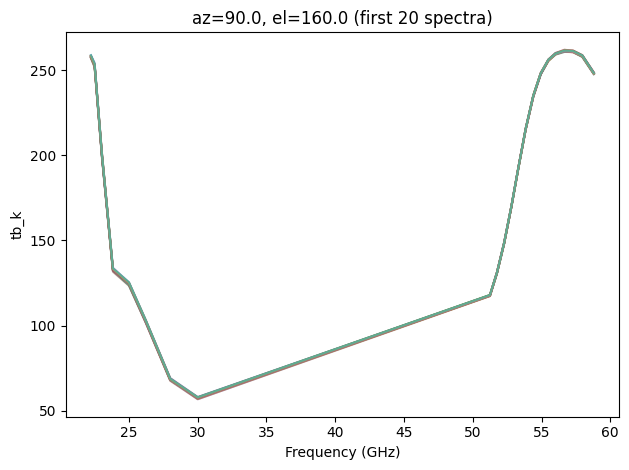

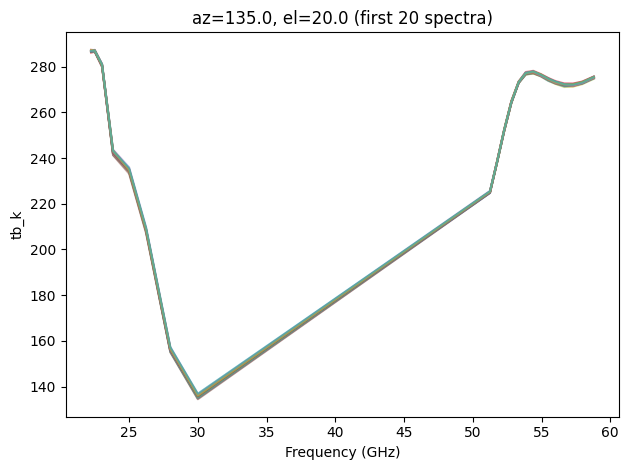

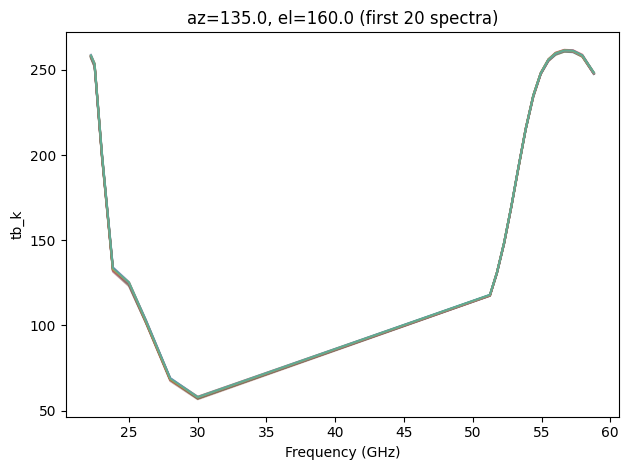

In [25]:
import matplotlib.pyplot as plt
from collections import defaultdict

# Clean data
df_clean = df.dropna(subset=["frequency_ghz", "tb_k"])

# Step 1: group into spectra
spectra = df_clean.groupby(["datetime_utc", "azimuth_deg", "elevation_deg"])

# Step 2: organize by (az, el)
azel_groups = defaultdict(list)
for (dt, az, el), group in spectra:
    azel_groups[(az, el)].append(group)

# Step 3: plot each (az, el) separately
for (az, el), group_list in azel_groups.items():
    
    plt.figure()  # new figure per combination
    
    for group in group_list[:20]:  # first 20 spectra
        group = group.sort_values("frequency_ghz")
        plt.plot(group["frequency_ghz"], group["tb_k"], alpha=0.5)
    
    plt.xlabel("Frequency (GHz)")
    plt.ylabel("tb_k")
    plt.title(f"az={az}, el={el} (first 20 spectra)")
    plt.tight_layout()
    plt.show()